# Multipoint lock-in: peak ADC counts vs reference ADC counts

This notebook reads the live multipoint lock-in CSV and compares each `peak_NN` MW-on ADC count against its paired `peak_NN_ref` off-resonance reference count. It is a post-processing notebook only; it does not touch the RFSoC or modify the acquisition notebook.

In [44]:
from io import BytesIO
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

def render(fig):
    buffer = BytesIO()
    fig.savefig(buffer, format="png", bbox_inches="tight")
    display(Image(data=buffer.getvalue()))
    plt.close(fig)

def _find_project_root() -> Path:
    p = Path.cwd().resolve()
    while p != p.parent and not (p / "pyproject.toml").exists():
        p = p.parent
    return p if (p / "pyproject.toml").exists() else Path.cwd()

PROJECT_ROOT = _find_project_root()
CSV_NAME = "multipoint_lockin_live_20260508_150009.csv"
CSV_PATH = PROJECT_ROOT / "data" / "lockin_multipoint" / CSV_NAME
if not CSV_PATH.exists():
    # fall back to cwd lookup (legacy behaviour)
    alt = Path.cwd() / CSV_NAME
    if alt.exists():
        CSV_PATH = alt

df = pd.read_csv(CSV_PATH)

peak_nums = []
for col in df.columns:
    match = re.fullmatch(r"peak_(\d{2})", col)
    if match and f"{col}_ref" in df.columns:
        peak_nums.append(int(match.group(1)))
peak_nums = sorted(peak_nums)

time_s = df["time_s"].to_numpy(dtype=float) if "time_s" in df.columns else np.arange(len(df), dtype=float)

print(f"CSV: {CSV_PATH.resolve()}")
print(f"Rows: {len(df)}")
print(f"Peak/reference pairs: {len(peak_nums)}")
print(f"Time span: {time_s[0]:.3f} to {time_s[-1]:.3f} s")

CSV: /Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/lockin_multipoint/multipoint_lockin_live_20260508_150009.csv
Rows: 529
Peak/reference pairs: 16
Time span: 0.013 to 42.238 s


## Summary by parked frequency

`peak_NN` is the MW-on ADC count at the parked signal frequency. `peak_NN_ref` is the paired off-resonance reference ADC count for that same point.

In [45]:
# Example: get first data point (row 0) for each peak/reference
single_point_rows = []
row_idx = 0  # First data point
for n in peak_nums:
    peak_col = f"peak_{n:02d}"
    ref_col = f"peak_{n:02d}_ref"
    freq_col = f"peak_{n:02d}_freq_mhz"

    signal = float(df.loc[row_idx, peak_col])
    reference = float(df.loc[row_idx, ref_col])
    freq = float(df.loc[row_idx, freq_col]) if freq_col in df.columns else np.nan
    diff = signal - reference
    ratio = signal / reference if reference != 0 else np.nan

    single_point_rows.append({
        "peak": peak_col,
        "freq_mhz": freq,
        "signal_adc": signal,
        "reference_adc": reference,
        "signal_minus_ref_adc": diff,
        "signal_over_ref": ratio,
    })

single_point_df = pd.DataFrame(single_point_rows)
display(single_point_df.round({
    "freq_mhz": 3,
    "signal_adc": 2,
    "reference_adc": 2,
    "signal_minus_ref_adc": 2,
    "signal_over_ref": 6,
}))

,peak,freq_mhz,signal_adc,reference_adc,signal_minus_ref_adc,signal_over_ref
0,peak_01,2629.0,6624.93,6634.14,-9.20,0.998613
1,peak_02,2631.0,6638.77,6637.65,1.13,1.000170
2,peak_03,2764.0,6613.42,6621.30,-7.88,0.998810
3,peak_04,2771.0,6610.67,6623.89,-13.22,0.998005
4,peak_05,2803.0,6619.85,6629.13,-9.28,0.998600
5,peak_06,2808.0,6626.13,6630.29,-4.16,0.999372
6,peak_07,2838.0,6624.72,6628.87,-4.15,0.999373
7,peak_08,2844.0,6628.43,6628.68,-0.24,0.999963
8,peak_09,2878.0,6601.25,6609.16,-7.90,0.998804
9,peak_10,2882.0,6594.52,6604.30,-9.78,0.998519


In [46]:
summary_rows = []
for n in peak_nums:
    peak_col = f"peak_{n:02d}"
    ref_col = f"peak_{n:02d}_ref"
    freq_col = f"peak_{n:02d}_freq_mhz"

    signal = df[peak_col].to_numpy(dtype=float)
    reference = df[ref_col].to_numpy(dtype=float)
    diff = signal - reference
    ratio = signal / reference

    summary_rows.append({
        "peak": peak_col,
        "freq_mhz": float(np.nanmedian(df[freq_col])) if freq_col in df.columns else np.nan,
        "signal_mean_adc": float(np.nanmean(signal)),
        "reference_mean_adc": float(np.nanmean(reference)),
        "signal_minus_ref_mean_adc": float(np.nanmean(diff)),
        "signal_minus_ref_std_adc": float(np.nanstd(diff, ddof=1)),
        "signal_over_ref_mean": float(np.nanmean(ratio)),
        "signal_over_ref_std": float(np.nanstd(ratio, ddof=1)),
    })

summary = pd.DataFrame(summary_rows)
display(summary.round({
    "freq_mhz": 3,
    "signal_mean_adc": 2,
    "reference_mean_adc": 2,
    "signal_minus_ref_mean_adc": 2,
    "signal_minus_ref_std_adc": 2,
    "signal_over_ref_mean": 6,
    "signal_over_ref_std": 6,
}))

,peak,freq_mhz,signal_mean_adc,reference_mean_adc,signal_minus_ref_mean_adc,signal_minus_ref_std_adc,signal_over_ref_mean,signal_over_ref_std
0,peak_01,2629.0,6630.39,6636.03,-5.64,4.83,0.999151,0.000728
1,peak_02,2631.0,6638.54,6642.54,-4.00,3.92,0.999399,0.000591
2,peak_03,2764.0,6620.89,6626.91,-6.01,6.42,0.999092,0.000972
3,peak_04,2771.0,6615.57,6624.69,-9.12,7.03,0.998624,0.001063
4,peak_05,2803.0,6619.30,6624.62,-5.32,5.46,0.999197,0.000825
5,peak_06,2808.0,6622.76,6627.77,-5.01,5.41,0.999245,0.000819
6,peak_07,2838.0,6626.70,6630.67,-3.97,3.93,0.999401,0.000593
7,peak_08,2844.0,6630.83,6633.97,-3.13,3.18,0.999528,0.000479
8,peak_09,2878.0,6596.68,6605.55,-8.87,6.97,0.998657,0.001057
9,peak_10,2882.0,6586.73,6600.35,-13.62,7.16,0.997937,0.001086


## Mean ADC count: signal vs reference for each parked point

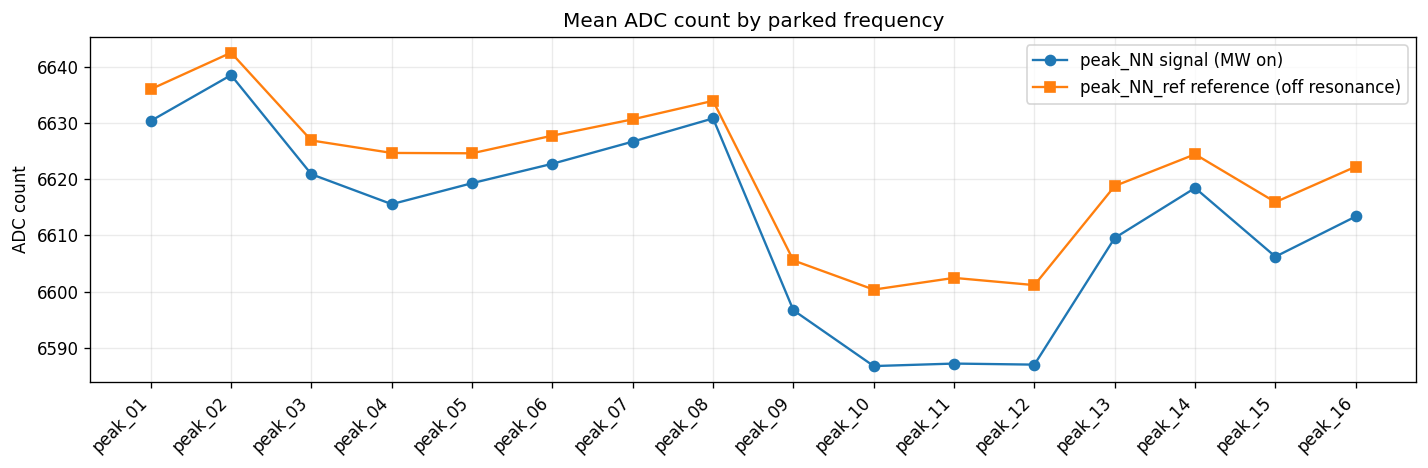

In [47]:
x = np.arange(len(summary))
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(x, summary["signal_mean_adc"], marker="o", lw=1.4, label="peak_NN signal (MW on)")
ax.plot(x, summary["reference_mean_adc"], marker="s", lw=1.4, label="peak_NN_ref reference (off resonance)")
ax.set_xticks(x)
ax.set_xticklabels(summary["peak"], rotation=45, ha="right")
ax.set_ylabel("ADC count")
ax.set_title("Mean ADC count by parked frequency")
ax.legend()
plt.tight_layout()
render(fig)

## Time-series overlay for every peak/reference pair

Each small plot overlays the signal count and off-resonance reference count from the same parked point.

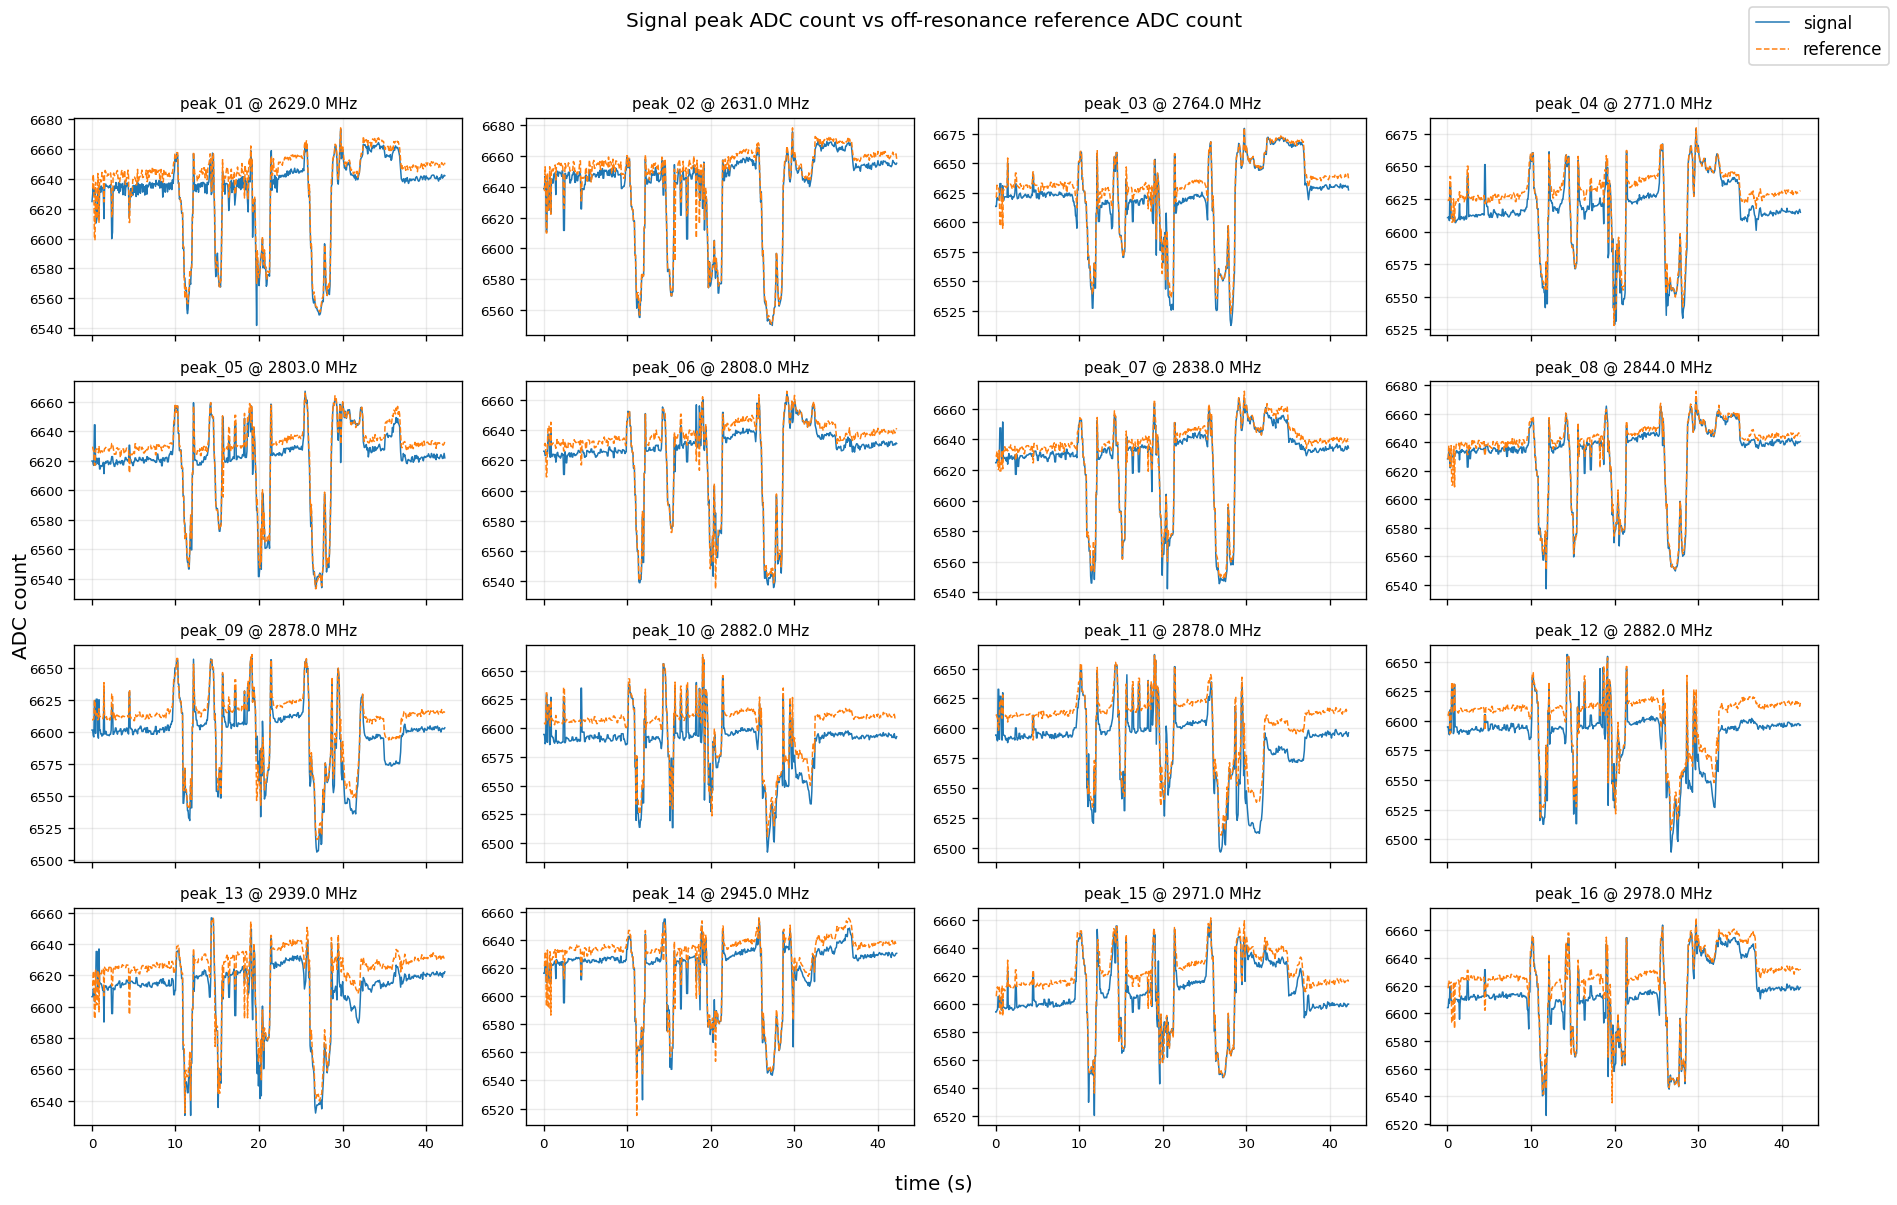

In [48]:
fig, axes = plt.subplots(4, 4, figsize=(16, 10), sharex=True)
axes = axes.ravel()

for ax, n in zip(axes, peak_nums):
    peak_col = f"peak_{n:02d}"
    ref_col = f"peak_{n:02d}_ref"
    freq_col = f"peak_{n:02d}_freq_mhz"
    freq = float(np.nanmedian(df[freq_col])) if freq_col in df.columns else np.nan

    ax.plot(time_s, df[peak_col], lw=0.9, label="signal")
    ax.plot(time_s, df[ref_col], lw=0.9, ls="--", label="reference")
    ax.set_title(f"{peak_col} @ {freq:.1f} MHz", fontsize=9)
    ax.tick_params(labelsize=8)

for ax in axes[len(peak_nums):]:
    ax.axis("off")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
fig.supxlabel("time (s)")
fig.supylabel("ADC count")
fig.suptitle("Signal peak ADC count vs off-resonance reference ADC count", y=0.995)
plt.tight_layout(rect=[0, 0, 0.97, 0.97])
render(fig)

## Signal minus reference over time

This plot makes it easier to see how far each signal point sits below its reference baseline.

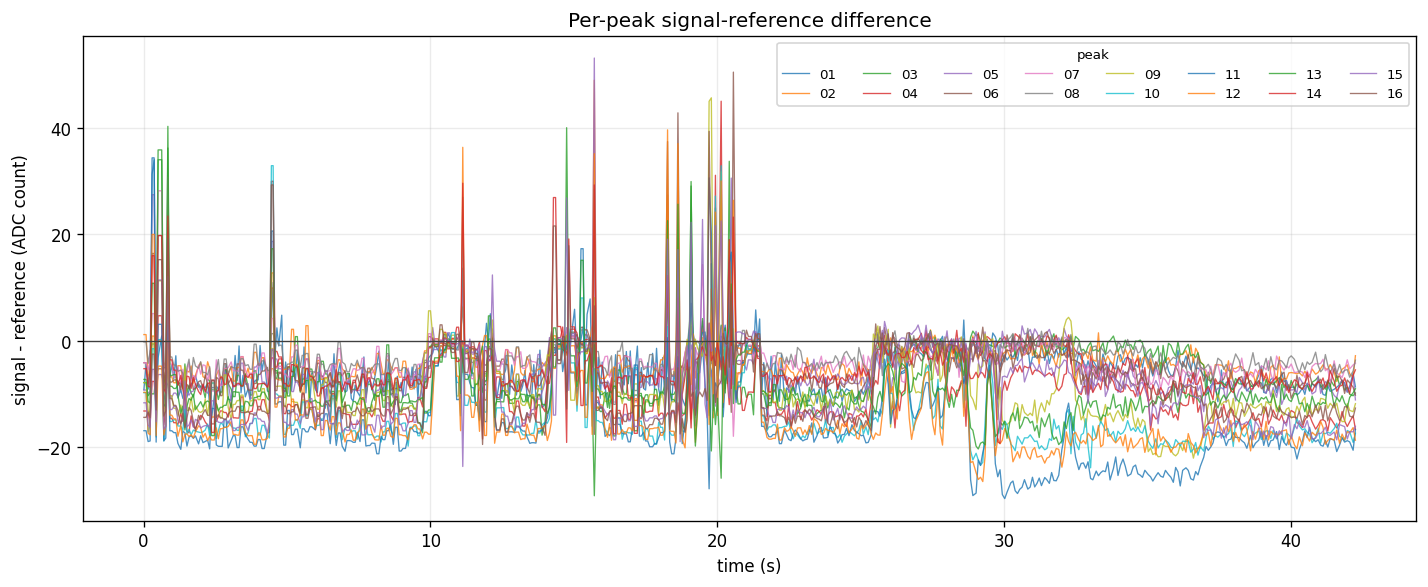

In [49]:
fig, ax = plt.subplots(figsize=(12, 5))
for n in peak_nums:
    peak_col = f"peak_{n:02d}"
    ref_col = f"peak_{n:02d}_ref"
    ax.plot(time_s, df[peak_col] - df[ref_col], lw=0.8, alpha=0.8, label=f"{n:02d}")

ax.axhline(0, color="0.25", lw=0.8)
ax.set_xlabel("time (s)")
ax.set_ylabel("signal - reference (ADC count)")
ax.set_title("Per-peak signal-reference difference")
ax.legend(title="peak", ncol=8, fontsize=8, title_fontsize=8)
plt.tight_layout()
render(fig)

## Scatter: reference ADC count vs signal ADC count

Each point is one live batch. The dashed line is `signal = reference`; points below that line have lower signal than reference.

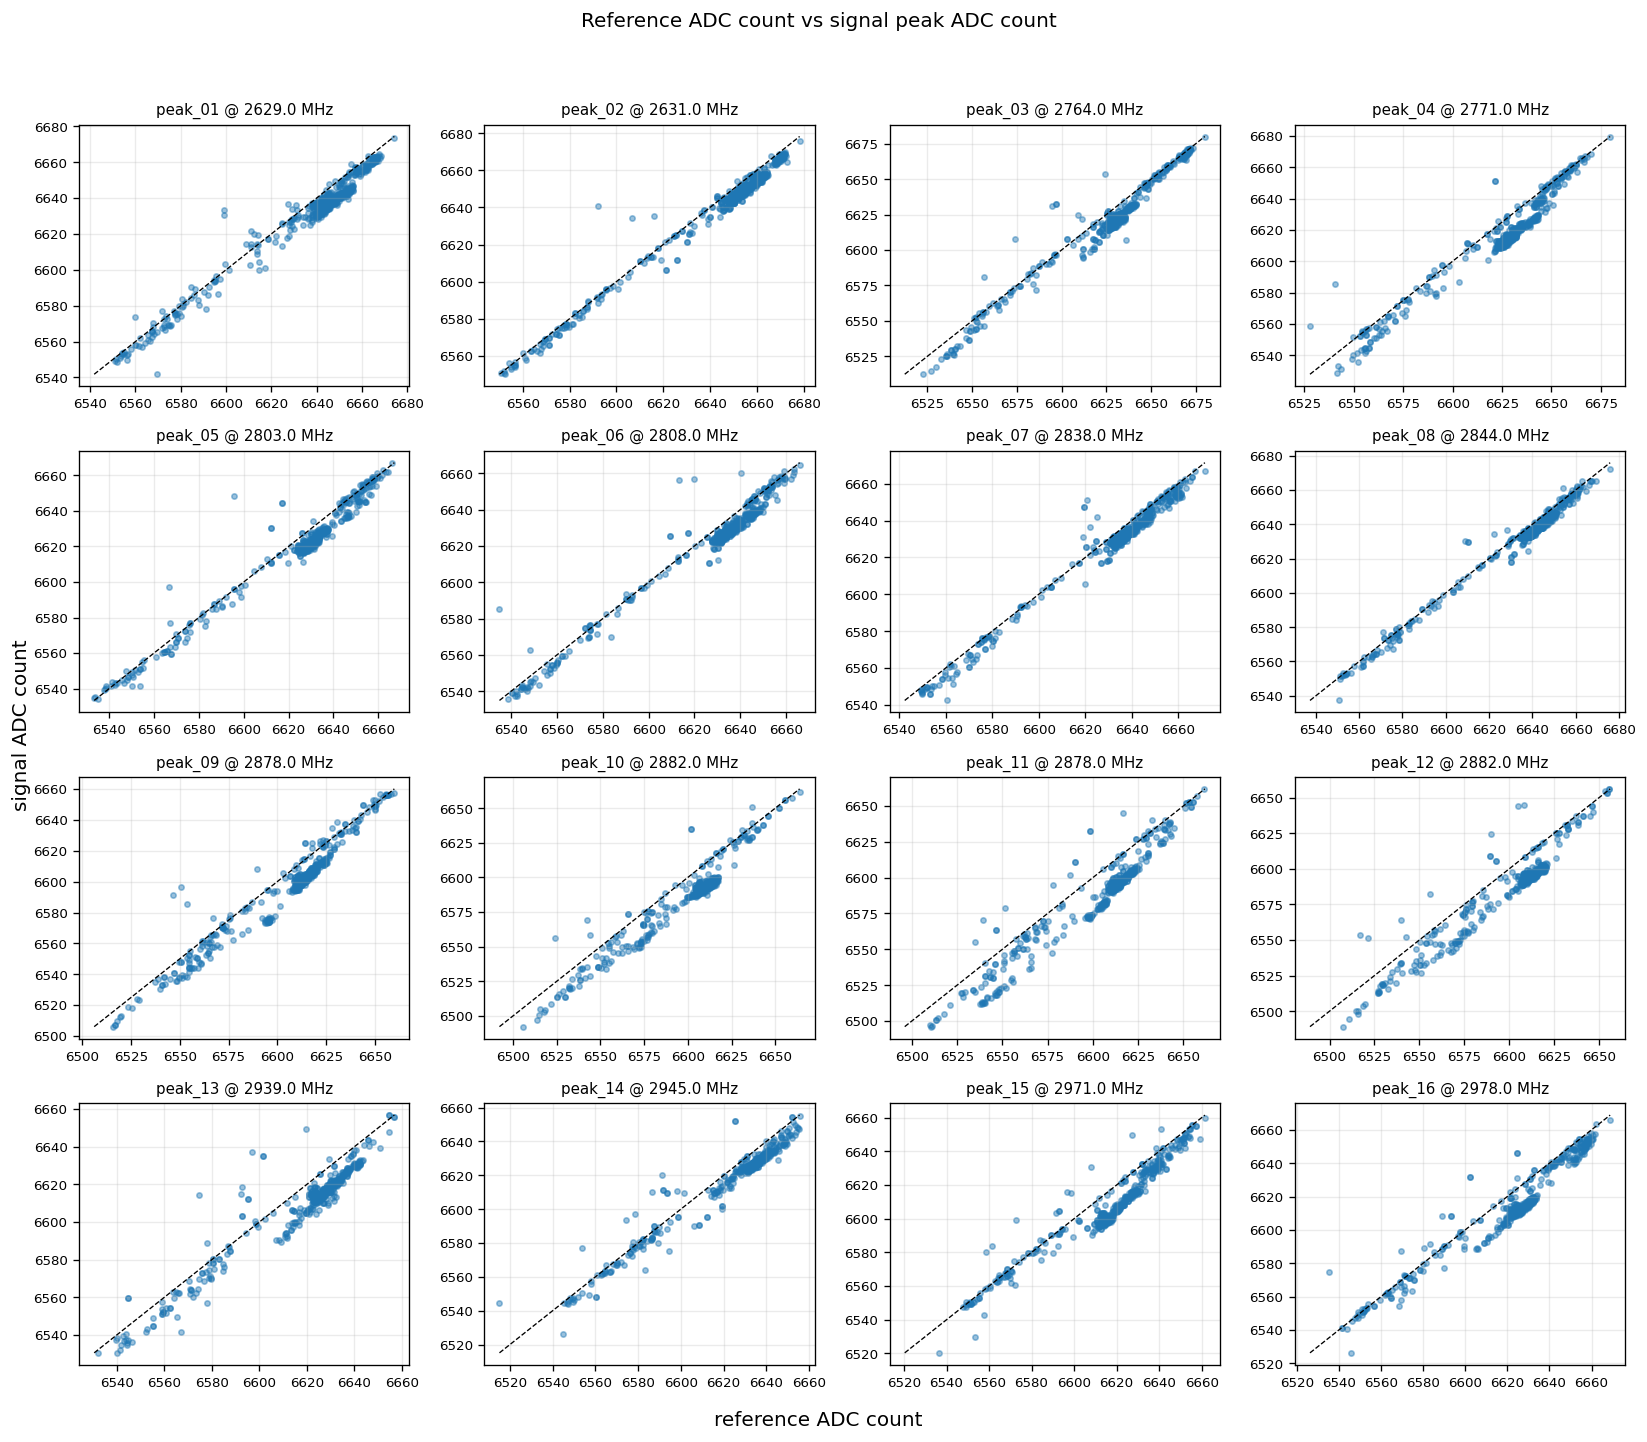

In [50]:
fig, axes = plt.subplots(4, 4, figsize=(14, 12))
axes = axes.ravel()

for ax, n in zip(axes, peak_nums):
    peak_col = f"peak_{n:02d}"
    ref_col = f"peak_{n:02d}_ref"
    freq_col = f"peak_{n:02d}_freq_mhz"
    freq = float(np.nanmedian(df[freq_col])) if freq_col in df.columns else np.nan

    x_ref = df[ref_col].to_numpy(dtype=float)
    y_sig = df[peak_col].to_numpy(dtype=float)
    lo = min(np.nanmin(x_ref), np.nanmin(y_sig))
    hi = max(np.nanmax(x_ref), np.nanmax(y_sig))

    ax.scatter(x_ref, y_sig, s=10, alpha=0.45)
    ax.plot([lo, hi], [lo, hi], "k--", lw=0.8)
    ax.set_title(f"{peak_col} @ {freq:.1f} MHz", fontsize=9)
    ax.tick_params(labelsize=8)

for ax in axes[len(peak_nums):]:
    ax.axis("off")

fig.supxlabel("reference ADC count")
fig.supylabel("signal ADC count")
fig.suptitle("Reference ADC count vs signal peak ADC count", y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.97])
render(fig)